$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Deep \space Learning $$
$$ Lab \space no. \space 3 $$

# `01` Assignment 01
- Design your own `deep NN` to classify the `CIFAR 10` images (you can download from keras.dataset) into one of the 10 classes
- Investigate the use of different architectures (`different layers`, `learning rate`, `optimizers`, `loss function`)
- Note you will need to `flatten` the image and use it as your input vector

## `+` Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, Conv2D, Activation, MaxPooling2D, AveragePooling2D,Input
from keras.models import Sequential
from keras.applications.resnet_v2 import ResNet50V2
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import MobileNet
from keras.datasets import cifar10
from keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt


## `+` Load & Preprocess CIFAR 10 Dataset

In [15]:
(X_train, y_train), (X_test, y_test) =cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [16]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 1)
Shape of X_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 1)


### Preview the Images

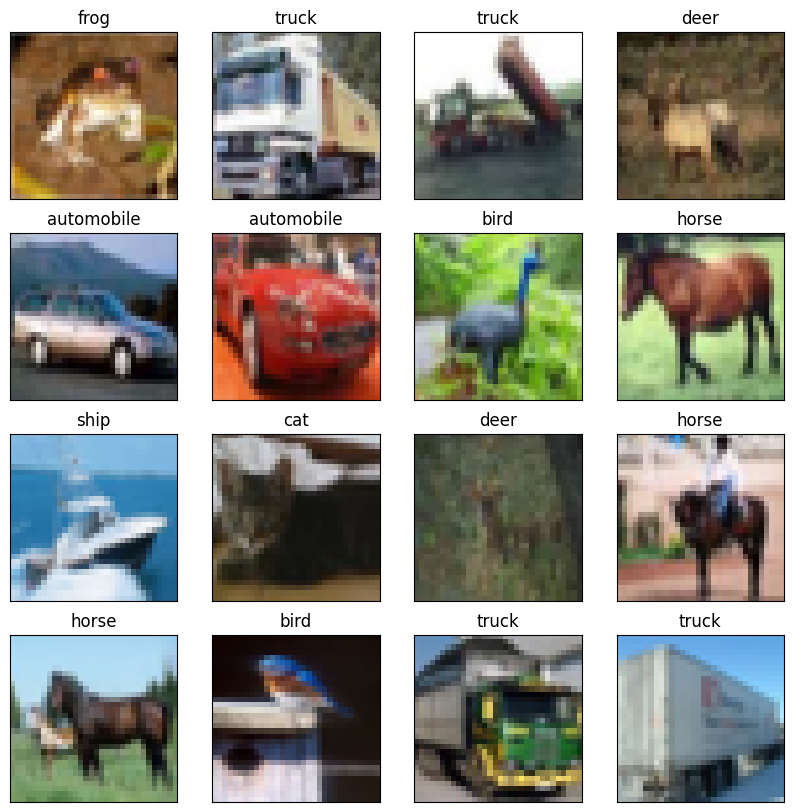

In [17]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
            
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=12)

plt.show()

### Feature Rescaling

In [6]:
# Rescale Input
X_train =X_train/.255
X_test  =X_test/.255

### OneHotEncode Target Variable

In [7]:
y_train =to_categorical(y_train)
y_test  =to_categorical(y_test)

## `+` Set Global Parameters

In [20]:
# Hyperparameters
BATCH_SIZE  =128
NUM_CLASSES =10
EPOCHS      =50

## `i` Trial no. 1

### Model Training

In [21]:
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])

In [22]:
history=model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_test,y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2552 - loss: 2.0046 - val_accuracy: 0.2738 - val_loss: 1.9602
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3687 - loss: 1.7476 - val_accuracy: 0.3423 - val_loss: 1.8076
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4100 - loss: 1.6413 - val_accuracy: 0.3806 - val_loss: 1.7183
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4373 - loss: 1.5816 - val_accuracy: 0.3909 - val_loss: 1.6610
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4529 - loss: 1.5346 - val_accuracy: 0.3839 - val_loss: 1.7680
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4606 - loss: 1.5086 - val_accuracy: 0.4099 - val_loss: 1.6635
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4727 - loss: 1.4744 - val_accuracy: 0.3886 - val_loss: 1.6874
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4834 - loss: 1.4440 - val_accuracy: 

### Model Evaluation

In [23]:
model.evaluate(X_train,y_train)
print("Accuracy for training:",model.evaluate(X_train,y_train)[1])
model.evaluate(X_test,y_test)
print("Accuracy for testing:",model.evaluate(X_test,y_test)[1])


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6118 - loss: 1.0885
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6118 - loss: 1.0885
Accuracy for training: 0.6095200181007385
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4921 - loss: 1.4906
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4921 - loss: 1.4906
Accuracy for testing: 0.49129998683929443


### Result Visualization

In [24]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

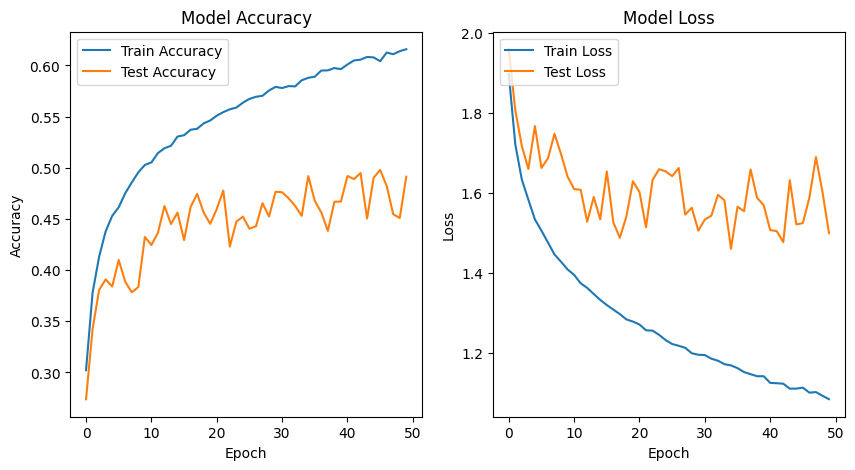

In [25]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()

## `ii` Trial no. 2

### Model Training

In [30]:
from tensorflow.keras.optimizers import SGD
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Flatten())
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(16,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
history=model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_test,y_test))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.1598 - loss: 2.2559 - val_accuracy: 0.2754 - val_loss: 1.9300
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2725 - loss: 1.9258 - val_accuracy: 0.3374 - val_loss: 1.8396
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3328 - loss: 1.8077 - val_accuracy: 0.3795 - val_loss: 1.7491
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3690 - loss: 1.7245 - val_accuracy: 0.3714 - val_loss: 1.7609
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3985 - loss: 1.6652 - val_accuracy: 0.3928 - val_loss: 1.6804
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4186 - loss: 1.6095 - val_accuracy: 0.3292 - val_loss: 1.8358
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4385 - loss: 1.5665 - val_accuracy: 0.3757 - val_loss: 1.7450
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4566 - loss: 1.5192 - val_accuracy: 

### Model Evaluation

In [32]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6350 - loss: 1.1316
Accuracy for training: 0.6322000026702881
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4776 - loss: 1.8150
Accuracy for testing: 0.46939998865127563


### Result Visualization

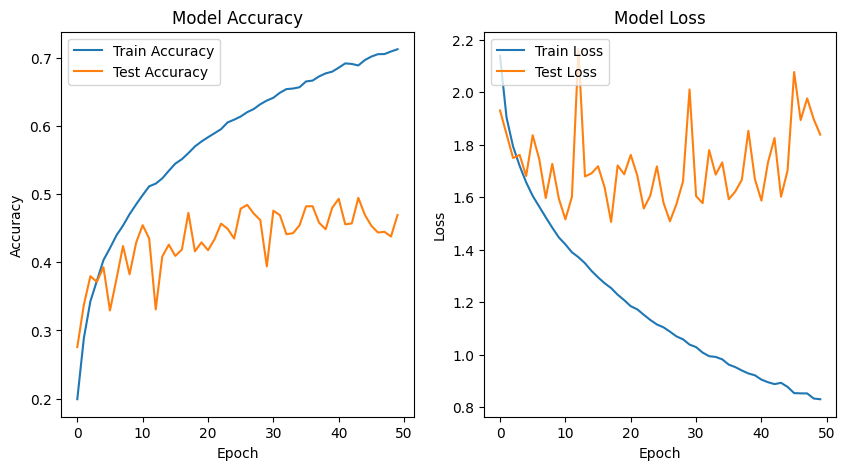

In [33]:
# Plot the training and validation accuracy and loss
# Plot the training and validation accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()

**Note:** Add more trials and explore different hyperparameters and design decisions.

------------------------------

# Assignment 02: Transfer Learning
- Design your `deep convolutional neural network` to classify the `CIFAR 10` images into one of the 10 classes
- Use a pre-trained model to boost your network.
- Invistage the use of different architectures (different `layers`, `kernel sizes`, `pooling`, `learning rate`, `optimizers`, `loss function`)

You have to specify filters and kernel_size. These parameters have no default.

Default padding is valid, which means no zero-padding, and the default strides is (1,1).

$\frac{N - F + 2P}{S} + 1$

$P = \frac{F - 1}{2}$

## `i` Trial no. 1

### Model Training

In [34]:
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [35]:
early_stopping=keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [36]:
model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_test,y_test),callbacks=[early_stopping])

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.2308 - loss: 2.0556 - val_accuracy: 0.4460 - val_loss: 1.5451
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4751 - loss: 1.4678 - val_accuracy: 0.4950 - val_loss: 1.4050
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5566 - loss: 1.2685 - val_accuracy: 0.5345 - val_loss: 1.4216
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6071 - loss: 1.1579 - val_accuracy: 0.6018 - val_loss: 1.1505
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6469 - loss: 1.0528 - val_accuracy: 0.6557 - val_loss: 1.0367
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6832 - loss: 0.9640 - val_accuracy: 0.6683 - val_loss: 1.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7076 - loss: 0.8864 - val_accuracy: 0.6735 - val_loss: 1.0233
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7396 - loss: 0.8095 - val_accuracy:

### Model Evaluation

In [37]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8998 - loss: 0.3161
Accuracy for training: 0.8994600176811218
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7036 - loss: 1.1913
Accuracy for testing: 0.70169997215271


### Result Visualization

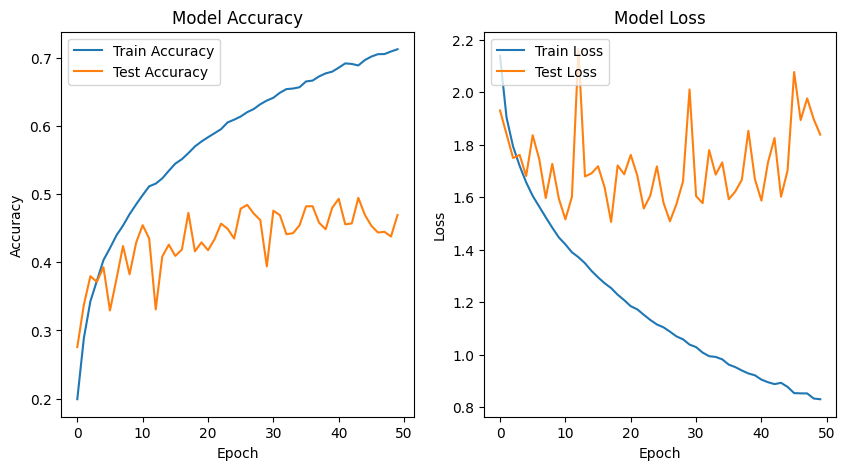

In [38]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


## `ii` Trial no. 2

### Model Training

In [48]:
pre_trained = VGG19(include_top=False, pooling='avg', weights='imagenet')
for layer in pre_trained.layers:
  layer.trainable = False
pre_trained.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)          │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [49]:
model = Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(pre_trained)
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [50]:
model.fit(X_train,y_train,batch_size=128,epochs=EPOCHS,validation_data=(X_test,y_test),callbacks=[early_stopping])

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4451 - loss: 1.6030 - val_accuracy: 0.5938 - val_loss: 1.1865
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.5806 - loss: 1.2029 - val_accuracy: 0.6068 - val_loss: 1.1351
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6041 - loss: 1.1266 - val_accuracy: 0.6164 - val_loss: 1.1032
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6236 - loss: 1.0781 - val_accuracy: 0.6236 - val_loss: 1.0872
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.6370 - loss: 1.0324 - val_accuracy: 0.6268 - val_loss: 1.0786
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.6470 - loss: 1.0002 - val_accuracy: 0.6346 - val_loss: 1.0621
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6590 - loss: 0.9708 - val_accuracy: 0.6387 - val_loss: 1.0516
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.6711 - loss: 0.9388 - 

### Model Evaluation

In [51]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8146 - loss: 0.5502
Accuracy for training: 0.8148199915885925
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6460 - loss: 1.0803
Accuracy for testing: 0.6489999890327454


### Result Visualization

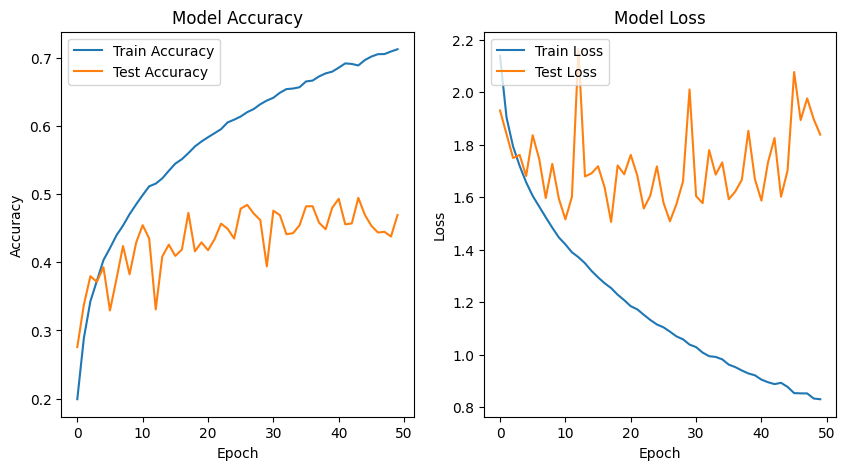

In [52]:
# Plot the training accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


---

# `03` Assignment 03
- Repeat Assignment 1 and 2 using MNIST dataset but do NOT use transfer learning this time (design the network from scratch)
- Note that you will need to convert the training labels into categorical using one hot encoding using `to_categorical()` function

## `+` Load MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) =keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


### OneHotEncode Target Variable

In [4]:
y_train =to_categorical(y_train)
y_test  =to_categorical(y_test)

### Preview the Images

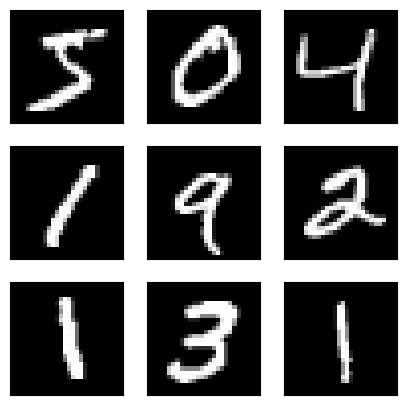

In [5]:
# plot first few images
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

### Rescale Independent Features

In [6]:
# Rescale the Input
X_train =X_train/.255
X_test  =X_test/.255

## `+` Set Global Parameters

In [7]:
# Hyperparameters
BATCH_SIZE  =32
NUM_CLASSES =10
EPOCHS      =50

## `i` ANN Trials

### Trial no. 1

#### Model Training

In [59]:
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [60]:
hoistory=model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_test,y_test))

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.8521 - loss: 0.4864 - val_accuracy: 0.9645 - val_loss: 0.1263
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9644 - loss: 0.1241 - val_accuracy: 0.9718 - val_loss: 0.0968
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9741 - loss: 0.0896 - val_accuracy: 0.9760 - val_loss: 0.0880
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9792 - loss: 0.0704 - val_accuracy: 0.9793 - val_loss: 0.0746
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9836 - loss: 0.0560 - val_accuracy: 0.9749 - val_loss: 0.0896
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9862 - loss: 0.0447 - val_accuracy: 0.9738 - val_loss: 0.0986
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0.9784 - val_loss: 0.0868
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9893 - loss: 0.0371

#### Model Ealuation

In [61]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9982 - loss: 0.0077
Accuracy for training: 0.9983000159263611
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9791 - loss: 0.1719
Accuracy for testing: 0.9829999804496765


#### Result Visualization

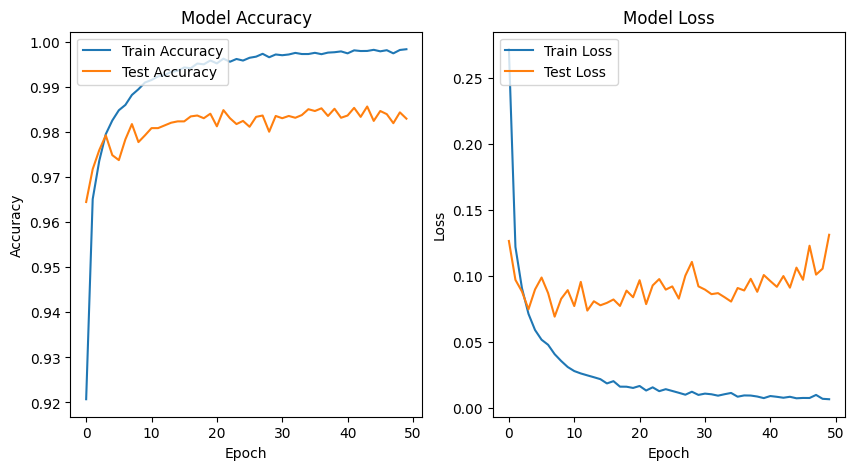

In [62]:
# Plot the training accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hoistory.history['accuracy'])
plt.plot(hoistory.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(hoistory.history['loss'])
plt.plot(hoistory.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


### Trial no. 2

#### Model Training

In [68]:
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
early_stopping=keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [70]:
history=model.fit(X_train,y_train,batch_size=32,epochs=30,validation_data=(X_test,y_test),callbacks=[early_stopping])

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8231 - loss: 0.5954 - val_accuracy: 0.9654 - val_loss: 0.1237
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9572 - loss: 0.1639 - val_accuracy: 0.9722 - val_loss: 0.1013
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9676 - loss: 0.1226 - val_accuracy: 0.9745 - val_loss: 0.0919
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9735 - loss: 0.0971 - val_accuracy: 0.9781 - val_loss: 0.0842
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9776 - loss: 0.0793 - val_accuracy: 0.9799 - val_loss: 0.0853
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9817 - loss: 0.0644 - val_accuracy: 0.9798 - val_loss: 0.0785
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9830 - loss: 0.0644 - val_accuracy: 0.9820 - val_loss: 0.0740
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9846 - loss: 0.051

#### Model Evaluation

In [71]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9980 - loss: 0.0066
Accuracy for training: 0.998033344745636
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.1211
Accuracy for testing: 0.9815999865531921


#### Result Visualization

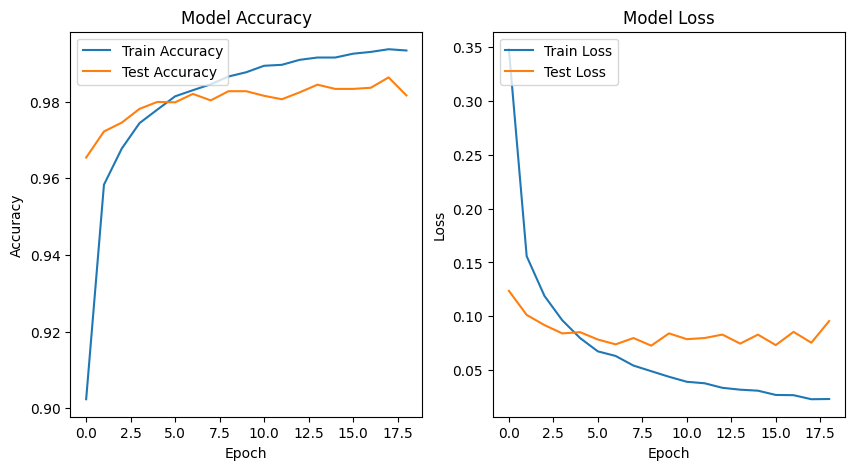

In [72]:
# Plot the training accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


## `ii` CNN Trials

### Trial no. 1

#### Datasets Reshaping

In [8]:
X_train =X_train.reshape(-1,28,28,1)
X_test =X_test.reshape(-1,28,28,1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

#### Model Training

In [75]:
model=Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [76]:
history=model.fit(X_train,y_train,batch_size=64,epochs=30,validation_data=(X_test,y_test),callbacks=[early_stopping])

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8442 - loss: 0.4997 - val_accuracy: 0.9659 - val_loss: 0.1128
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9777 - loss: 0.0762 - val_accuracy: 0.9790 - val_loss: 0.0724
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9832 - loss: 0.0548 - val_accuracy: 0.9759 - val_loss: 0.0764
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9874 - loss: 0.0424 - val_accuracy: 0.9823 - val_loss: 0.0613
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9893 - loss: 0.0349 - val_accuracy: 0.9862 - val_loss: 0.0477
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9898 - loss: 0.0330 - val_accuracy: 0.9873 - val_loss: 0.0480
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9859 - val_loss: 0.0520
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9925 - loss: 0.0233 - val_accuracy: 

#### Model Evaluation

In [77]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9988 - loss: 0.0037
Accuracy for training: 0.9987000226974487
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0634
Accuracy for testing: 0.9894999861717224


#### Result Visualization

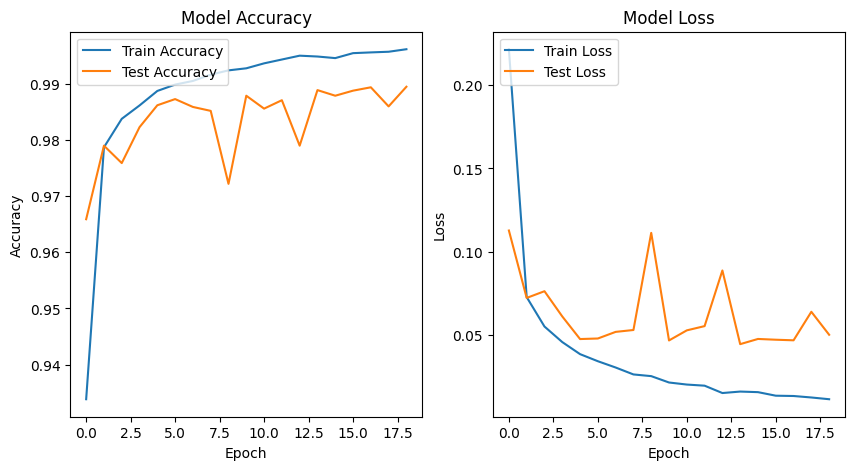

In [78]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


### Trial no. 2

#### Model Training

In [10]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
his=model.fit(X_train,y_train,batch_size=128,epochs=30,validation_data=(X_test,y_test),callbacks=early_stopping)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8555 - loss: 0.4578 - val_accuracy: 0.9840 - val_loss: 0.0558
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9797 - loss: 0.0749 - val_accuracy: 0.9904 - val_loss: 0.0394
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9868 - loss: 0.0528 - val_accuracy: 0.9876 - val_loss: 0.0440
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9903 - loss: 0.0350 - val_accuracy: 0.9897 - val_loss: 0.0366
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.0361 - val_accuracy: 0.9929 - val_loss: 0.0294
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9934 - loss: 0.0229 - val_accuracy: 0.9887 - val_loss: 0.0422
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9936 - loss: 0.0224 - val_accuracy: 0.9899 - val_loss: 0.0450
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9940 - loss: 0.0210 - val_accuracy: 

#### Model Evaluation

In [12]:
out=model.evaluate(X_train,y_train)
print("Accuracy for training:",out[1])
test_out=model.evaluate(X_test,y_test)
print("Accuracy for testing:",test_out[1])


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9984 - loss: 0.0053
Accuracy for training: 0.998283326625824
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0455
Accuracy for testing: 0.9926000237464905


#### Result Visualization

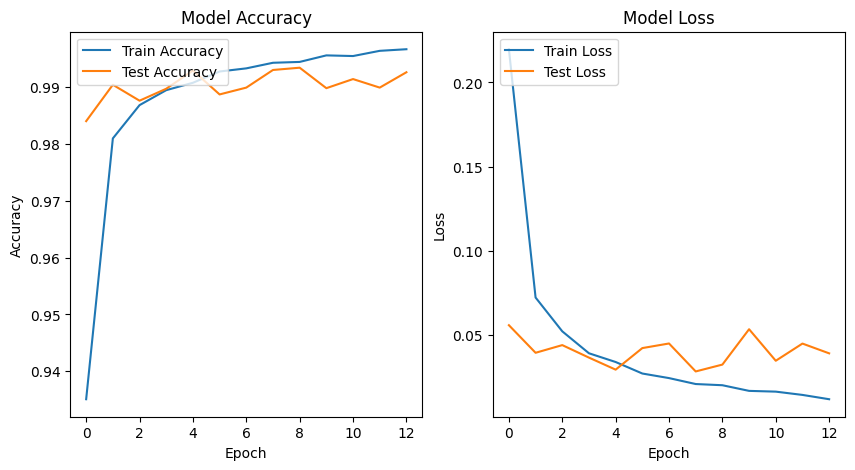

In [13]:
# Plot the training accuracy and loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(his.history['accuracy'])
plt.plot(his.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Test Accuracy'], loc='upper left')
plt.subplot(1,2,2)
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Test Loss'], loc='upper left')
plt.show()


----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$